# Disease Prediction Model

**Objective**: Predict whether the applicant has the disease or not.

**Dataset**: Cleveland dataset (UCI Machine Learning Repository) - 303 applicants, 14 features, binary target (Positive / Negative).

**Approach**: Logistic Regression, Decision Trees and Random Forest, compared on Precision, Recall, F1-score and ROC-AUC.

## 1. Load the data

Importing all the necessary libraries. Exploring the data, looking at what we're going to work with.

In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', None)

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num' 
]

 
df = pd.read_csv('processed.cleveland.data', header = None, names = columns, na_values='?')
df['num'] = df['num'].apply(lambda x:1 if x>0 else 0)


**Note:** So I kind of ran into a problem. I was mapping the diagnosis to 0 and 1 using the following format:
 **df['num'] = df['num'].map({1:0, 2:1})**
 But, it turns out values other than 1 and 0 will be declared NaN (Not a Number). As the dataset diagnosis according to severity (0-4), I've used apply() to resolve this issue for now. In the future, maybe I will also display the severity as well, but for now just the yes or no diagnosis is fine.
 **df['target'] = df['target'].map({
    0: 0,
    1: 1,
    2: 1,
    3: 1,
    4: 1
})** it can also be done this way.


Another thing, **na_values='?'** prevents '?' strings in columns that cannot be converted into numerical values. It helps when you compute correlation on columns.

# 2. Exploratory Data Analysis



In [23]:
print(df.head())
display(Markdown("<br>**Dataset Info:**"))
print(df.info())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    1  
2    2.0  2.0   7.0    1  
3    3.0  0.0   3.0    0  
4    1.0  0.0   3.0    0  


<br>**Dataset Info:**

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [24]:
print(df['num'].value_counts())

num
0    164
1    139
Name: count, dtype: int64


In [25]:
df['num'].value_counts(normalize=False).rename({0:'Healthy', 1:'Disease'})

num
Healthy    164
Disease    139
Name: count, dtype: int64

In [26]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


**Note**: There are no null values in this dataset. If there were, then we could either drop rows from features that contain the null values (**df_clean=df.dropna()**) or we could use scikit-learn's **SimpleImputer**

**Checking class imbalance**

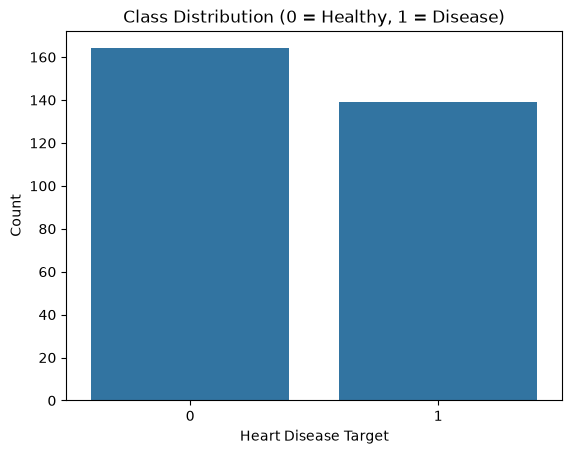

In [27]:
sns.countplot(x='num', data=df)
plt.title('Class Distribution (0 = Healthy, 1 = Disease)')
plt.xlabel('Heart Disease Target')
plt.ylabel('Count')
plt.show()

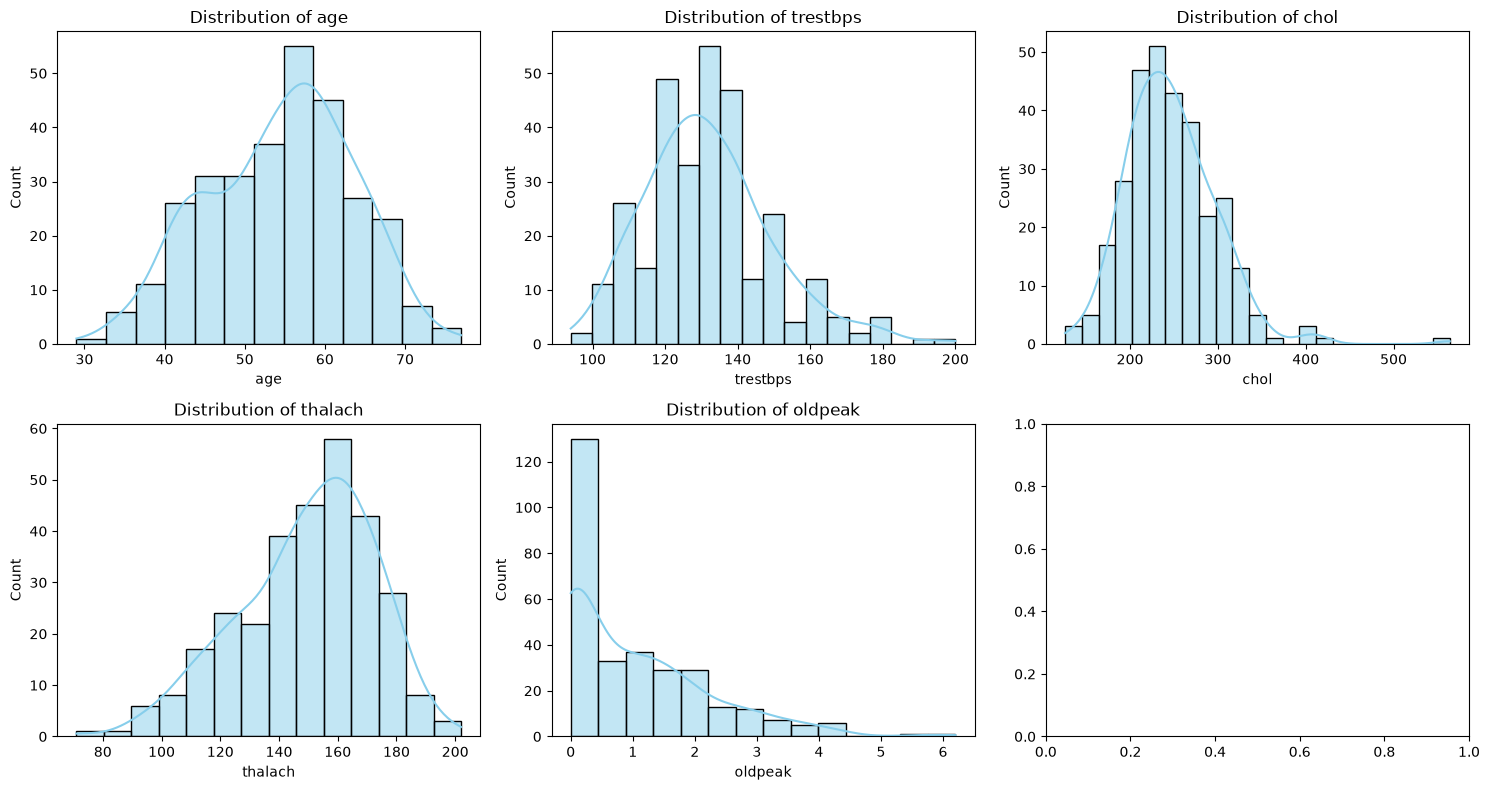

In [29]:
fig, axis = plt.subplots(2, 3, figsize=(15, 8))
num_features = ['age','trestbps','chol', 'thalach', 'oldpeak']

for ax, feature in zip(axis.flatten(), num_features):
    sns.histplot(df[feature], kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

**age** is pretty symmetrical and will require just StandardScaler.

**trestbps** is slightly right-skewed. StandardScaler will do just fine.

**chol** is right-skewed with extreme outlier, will require RobustScaler first.

**thalach** is mildly skewed, will only need StandardScaler.

**oldpeak** is heavily right-skewed, will require Log1p Transformation first.

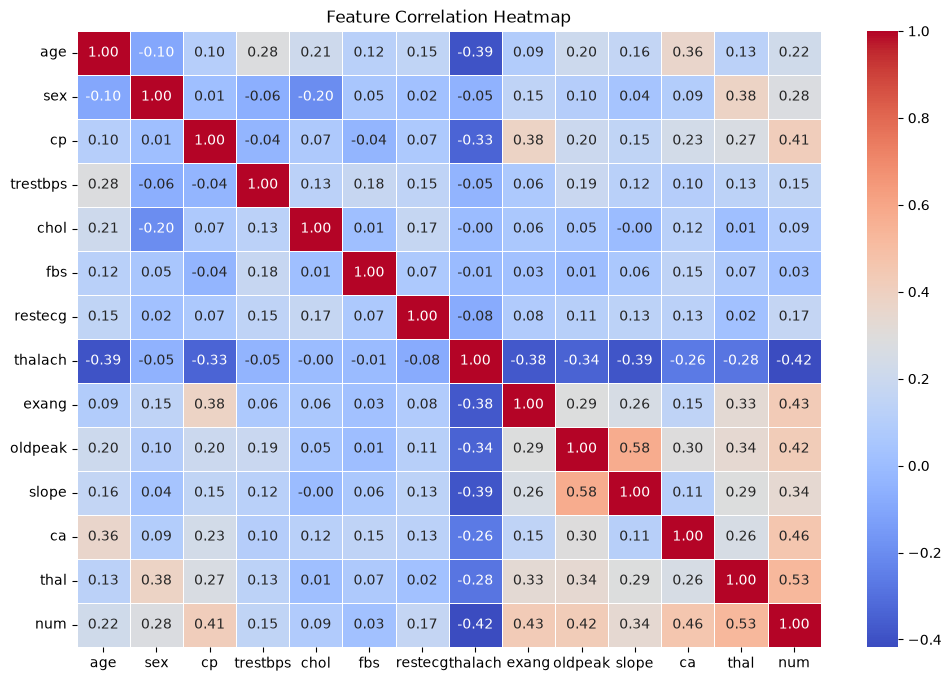

In [30]:
plt.figure(figsize=(12, 8))
corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

**_Top Positive Predictiors:_**
**thal**(Thalassemia) and **ca**(number of major vessels colored by fluoroscopy) have the most positive correlation with heart-diseaee likelihood.

**exang**(Exercise-induced angina), **cp**(chest pain Type) and **oldpeak**(ST depression) have solid positive correlations as well.

**sex** has moderate positive correlation.

**_Top Negative Predictors:_**
**thalach**(Maximum heart-rate achieved) has the most negative correlation.

**_Irrelevant Features:_**
**fbs**(Fasting blood sugar), **chol**(Cholesterol) show virtually zero correlation with num.

**Checking for Multicollinearity:-**

**slope** and **oldpeak** have the highest inter-feature correlation in the dataset(0.58). Still it is less than 0.70, so no features need to be dropped.

**thalach** and **age**, **slope** have the lowest inter-feature correlation(-0.39). Again, we donot go below -0.70, so we're good.

## 3. Preprocess the data

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

